In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md


import kagglehub
path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")

print("Path to dataset files:", path)

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv
Path to dataset files: /kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv(path+"/tesla_deliveries_dataset_2015_2025.csv")

In [7]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [9]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [10]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [11]:
df["Model"].value_counts()

Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

In [12]:
#MEAN OF SLAES PRICE(AVG.) RESGIONWISE
#DETERMINES THE AVG SALES PRICE MEANS REGIONWISE
df.groupby("Region")["Avg_Price_USD"].mean()

Region
Asia             85161.733773
Europe           86107.731939
Middle East      84535.999091
North America    83823.896515
Name: Avg_Price_USD, dtype: float64

In [13]:
#YEAR WISE DELIVERIES ANALYSIS
year = df.groupby("Year")["Estimated_Deliveries"].sum()
print(year)

Year
2015    2375267
2016    2434081
2017    2350517
2018    2423104
2019    2404230
2020    2280336
2021    2335116
2022    2434220
2023    2382375
2024    2406899
2025    2368462
Name: Estimated_Deliveries, dtype: int64


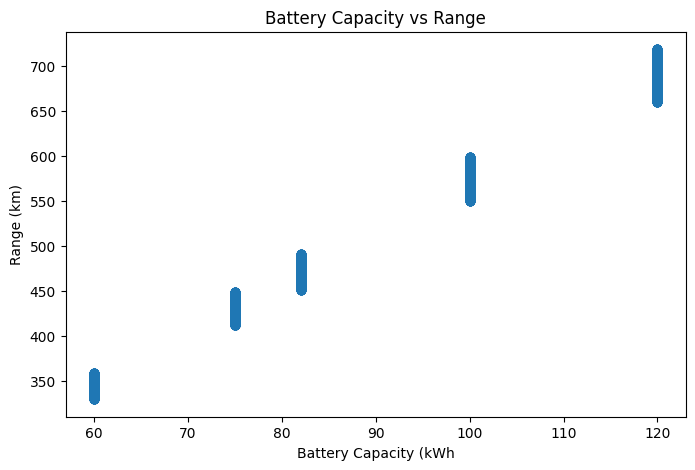

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["Battery_Capacity_kWh"],
    df["Range_km"]
)
plt.xlabel("Battery Capacity (kWh")
plt.ylabel("Range (km)")
plt.title("Battery Capacity vs Range")
plt.show()

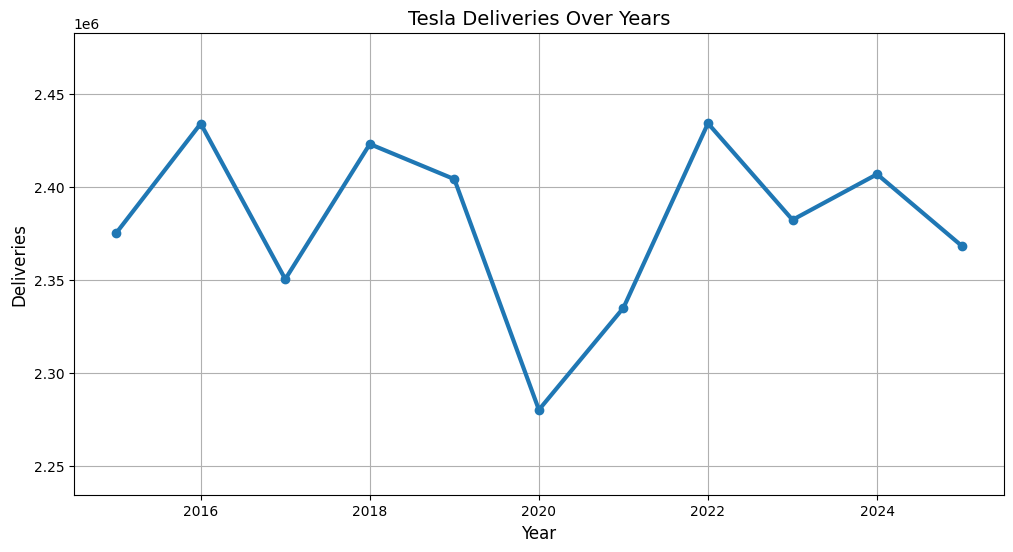

In [15]:
import matplotlib.pyplot as plt
yearly = df.groupby("Year")["Estimated_Deliveries"].sum()
plt.figure(figsize=(12,6))

plt.plot(
    yearly.index,
    yearly.values,
    marker="o",
    linewidth=3
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Deliveries", fontsize=12)
plt.title("Tesla Deliveries Over Years", fontsize=14)

plt.grid(True)

plt.ylim(
    yearly.min() * 0.98,
    yearly.max() * 1.02
)

plt.show()

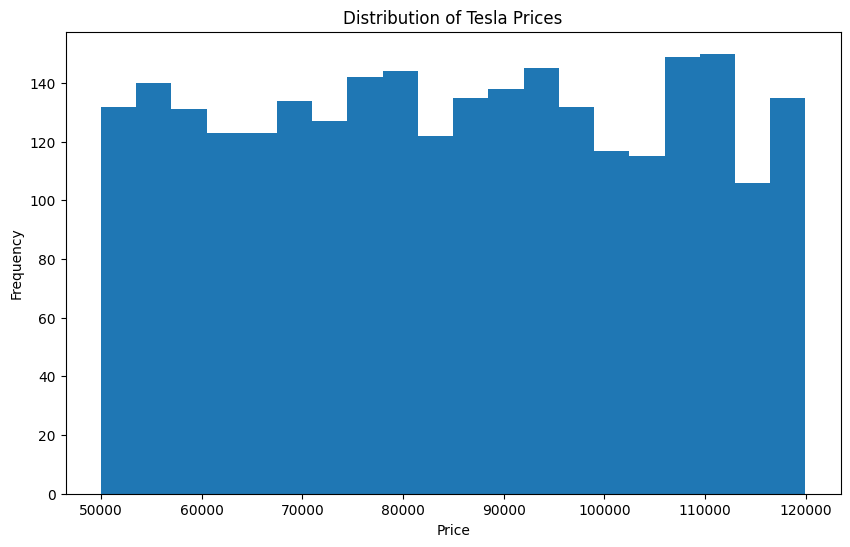

In [16]:
plt.figure(figsize=(10,6))
plt.hist(df["Avg_Price_USD"], bins=20)
plt.title("Distribution of Tesla Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

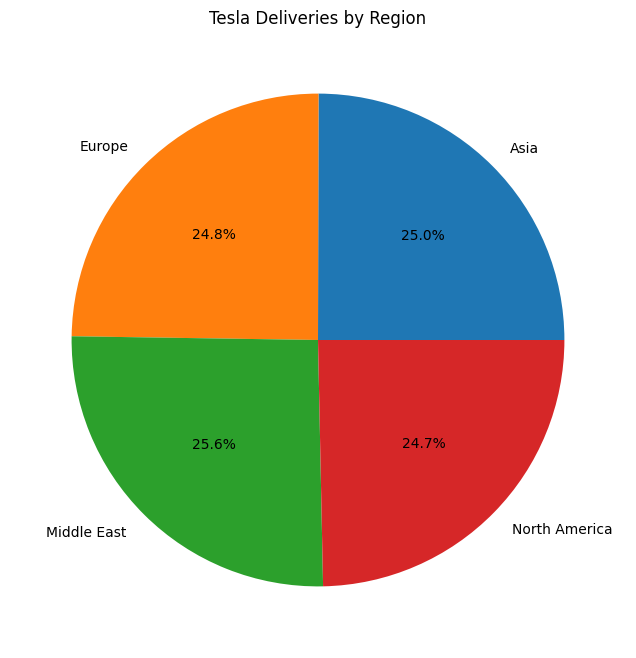

In [17]:
region_sales = df.groupby("Region")["Estimated_Deliveries"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    region_sales.values,
    labels=region_sales.index,
    autopct="%1.1f%%"
)

plt.title("Tesla Deliveries by Region")

plt.show()

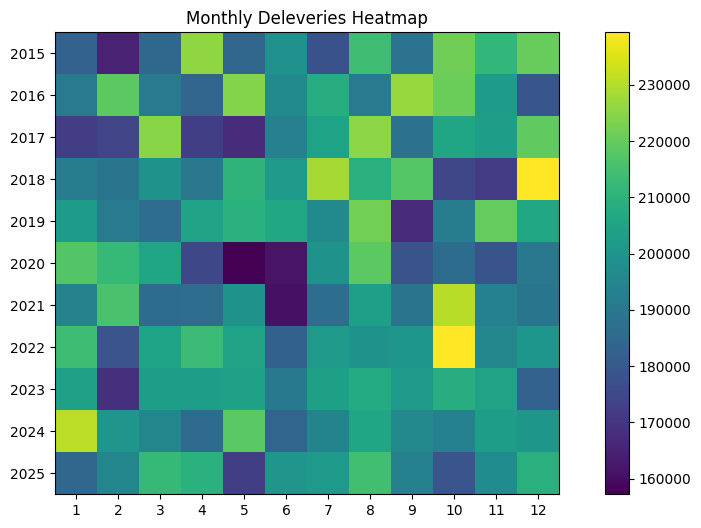

In [18]:
pivot = df.pivot_table(
    values = "Estimated_Deliveries",
    index = "Year",
    columns = "Month",
    aggfunc = "sum"
)

plt.figure(figsize=(12,6))
plt.imshow(pivot)
plt.colorbar()

plt.xticks(range(12),pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)

plt.title("Monthly Deleveries Heatmap")

plt.show()

In [19]:
X = df[[
    "Year",
    "Month",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations"
]]

y = df["Estimated_Deliveries"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(2112, 8)
(528, 8)


In [21]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [22]:
lr_pred = lr.predict(X_test)

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error

print("Linear Regression")

print("R2:",
      r2_score(y_test, lr_pred))

print("MAE:",
      mean_absolute_error(y_test, lr_pred))

Linear Regression
R2: 0.9901595854768158
MAE: 309.708165264122


In [24]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [25]:
rf_pred = rf.predict(X_test)

In [26]:
print("Random Forest")

print("R2:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))

Random Forest
R2: 0.9893103793226311
MAE: 314.13619318181816


In [28]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [30]:
best_rf = grid.best_estimator_
best_pred = best_rf.predict(X_test)

In [33]:
print("Tuned RF")
print("R2:", r2_score(y_test, best_pred))
print("MAE:", mean_absolute_error(y_test, best_pred))

Tuned RF
R2: 0.9894521149703156
MAE: 311.9404924242424


In [34]:
comparison = {
    "Linear Regression":
        r2_score(y_test, lr_pred),

    "Random Forest":
        r2_score(y_test, rf_pred),

    "Tuned Random Forest":
        r2_score(y_test, best_pred)
}

print(comparison)

{'Linear Regression': 0.9901595854768158, 'Random Forest': 0.9893103793226311, 'Tuned Random Forest': 0.9894521149703156}


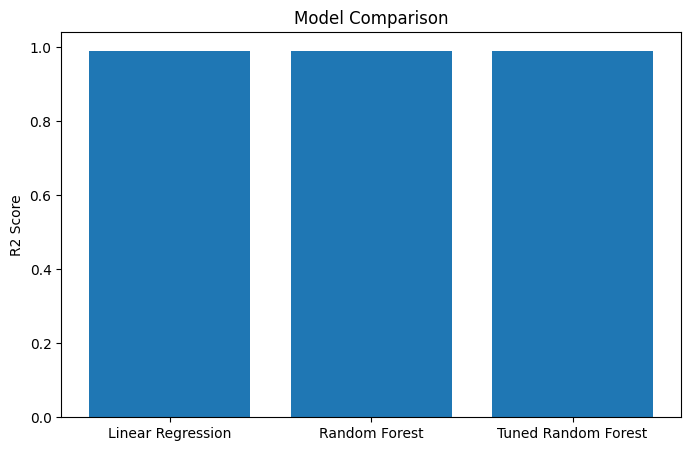

In [35]:
import matplotlib.pyplot as plt

models = comparison.keys()
scores = comparison.values()

plt.figure(figsize=(8,5))
plt.bar(models, scores)
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

In [36]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importances = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                Feature  Importance
0                  Year    0.000955
1                 Month    0.000861
2      Production_Units    0.990923
3         Avg_Price_USD    0.001488
4  Battery_Capacity_kWh    0.000196
5              Range_km    0.001650
6        CO2_Saved_tons    0.002625
7     Charging_Stations    0.001301


In [37]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str)
)
print(df[["Year","Month","Date"]].head())

   Year  Month       Date
0  2023      5 2023-05-01
1  2015      2 2015-02-01
2  2019      1 2019-01-01
3  2021      2 2021-02-01
4  2016     12 2016-12-01


In [38]:
monthly = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
      .reset_index()
)
print(monthly.head())

        Date  Estimated_Deliveries
0 2015-01-01                183180
1 2015-02-01                165053
2 2015-03-01                184567
3 2015-04-01                225623
4 2015-05-01                184264


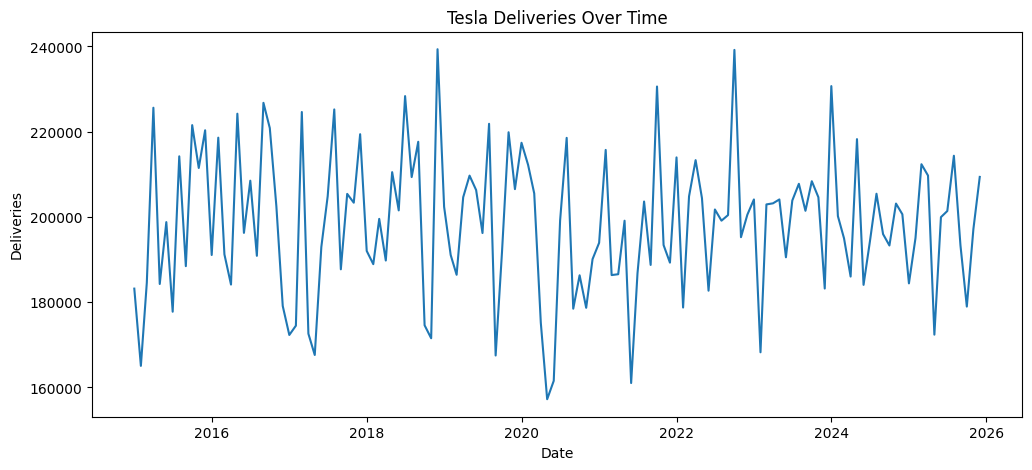

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    monthly["Date"],
    monthly["Estimated_Deliveries"]
)

plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.show()

In [40]:
import numpy as np
monthly["Time"] = np.arange(len(monthly))

In [41]:
from sklearn.linear_model import LinearRegression

X = monthly[["Time"]]
y = monthly["Estimated_Deliveries"]

model = LinearRegression()

model.fit(X, y)
monthly["Predicted"] = model.predict(X)

In [42]:
future_time = np.arange(
    len(monthly),
    len(monthly)+12
).reshape(-1,1)

forecast = model.predict(future_time)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [43]:
future_dates = pd.date_range(
    start=monthly["Date"].max(),
    periods=13,
    freq="ME"
)[1:]

In [44]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": forecast
})

print(forecast_df)

         Date       Forecast
0  2026-01-31  198436.571015
1  2026-02-28  198436.459415
2  2026-03-31  198436.347815
3  2026-04-30  198436.236215
4  2026-05-31  198436.124615
5  2026-06-30  198436.013015
6  2026-07-31  198435.901415
7  2026-08-31  198435.789815
8  2026-09-30  198435.678214
9  2026-10-31  198435.566614
10 2026-11-30  198435.455014
11 2026-12-31  198435.343414
